In [1]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Loading the Global Superstore dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Checking the number of rows and columns in the dataset
df.shape

(9994, 21)

In [4]:
# Checking the column names and data types
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [5]:
# Checking for missing values in each column
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
# Basic statistical summary of the dataset
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


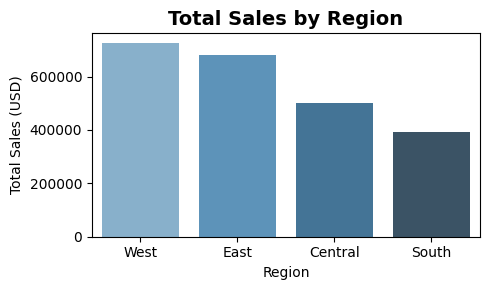

In [16]:
# Visualizing total sales by region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(5, 3))
sns.barplot(x=region_sales.index, y=region_sales.values, hue=region_sales.index,
            palette='Blues_d', legend=False)
plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales (USD)')
plt.tight_layout()
plt.savefig('viz1_sales_by_region.png', dpi=150)
plt.show()

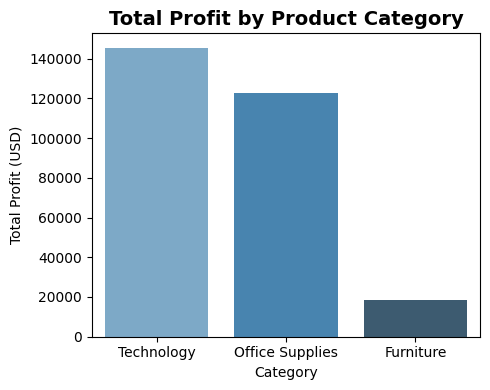

In [21]:
# Visualizing total profit by product category
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(5, 4))
sns.barplot(x=category_profit.index, y=category_profit.values, hue=category_profit.index,
            palette='Blues_d', legend=False)
plt.title('Total Profit by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Profit (USD)')
plt.tight_layout()
plt.savefig('viz2_profit_by_category.png', dpi=150)
plt.show()

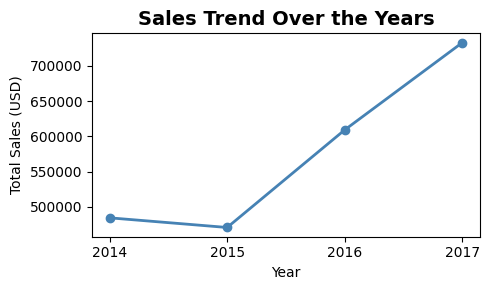

In [19]:
# Visualizing sales trend over the years
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(5, 3))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', color='steelblue', linewidth=2)
plt.title('Sales Trend Over the Years', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Sales (USD)')
plt.xticks(yearly_sales.index)
plt.tight_layout()
plt.savefig('viz3_sales_trend.png', dpi=150)
plt.show()

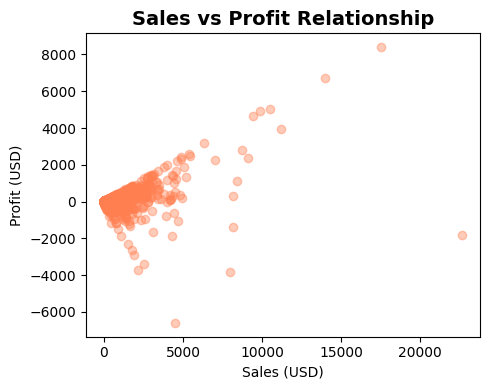

In [22]:
# Visualizing the relationship between sales and profit
plt.figure(figsize=(5, 4))
plt.scatter(df['Sales'], df['Profit'], alpha=0.4, color='coral')
plt.title('Sales vs Profit Relationship', fontsize=14, fontweight='bold')
plt.xlabel('Sales (USD)')
plt.ylabel('Profit (USD)')
plt.tight_layout()
plt.savefig('viz4_sales_vs_profit.png', dpi=150)
plt.show()

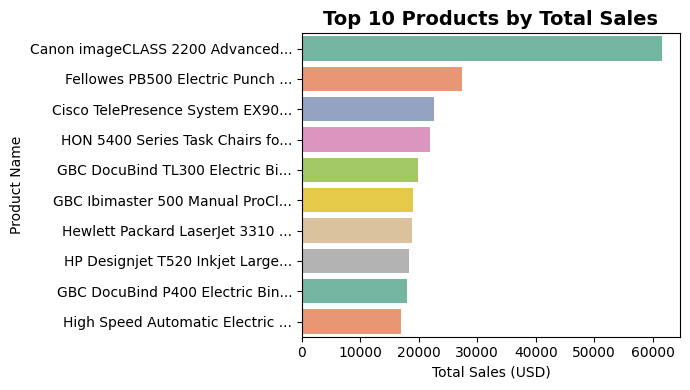

In [11]:
# Visualizing the top 10 products by total sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.index = [name[:30] + '...' for name in top_products.index]

plt.figure(figsize=(7, 4))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index,
            palette='Set2', legend=False)
plt.title('Top 10 Products by Total Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales (USD)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.savefig('viz5_top10_products.png', dpi=150)
plt.show()

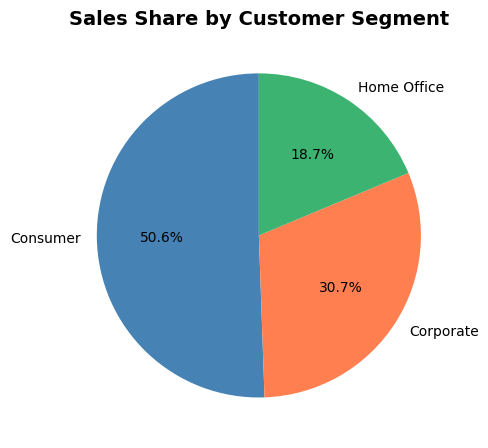

In [12]:
# Visualizing sales share by customer segment
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(5, 5))
plt.pie(segment_sales.values, labels=segment_sales.index, autopct='%1.1f%%',
        colors=['steelblue', 'coral', 'mediumseagreen'], startangle=90)
plt.title('Sales Share by Customer Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz6_sales_by_segment.png', dpi=150)
plt.show()

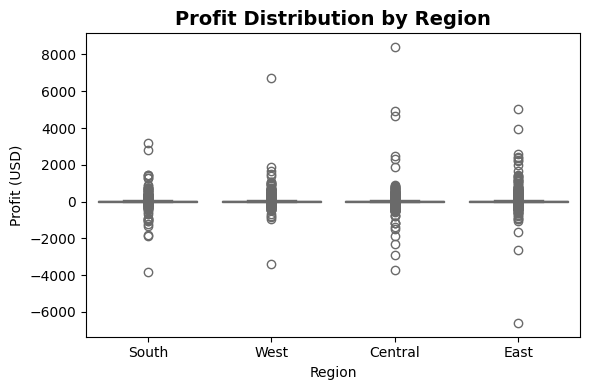

In [13]:
# Visualizing profit distribution by region
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Region', y='Profit', hue='Region',
            palette='Set3', legend=False)
plt.title('Profit Distribution by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Profit (USD)')
plt.tight_layout()
plt.savefig('viz7_profit_by_region.png', dpi=150)
plt.show()

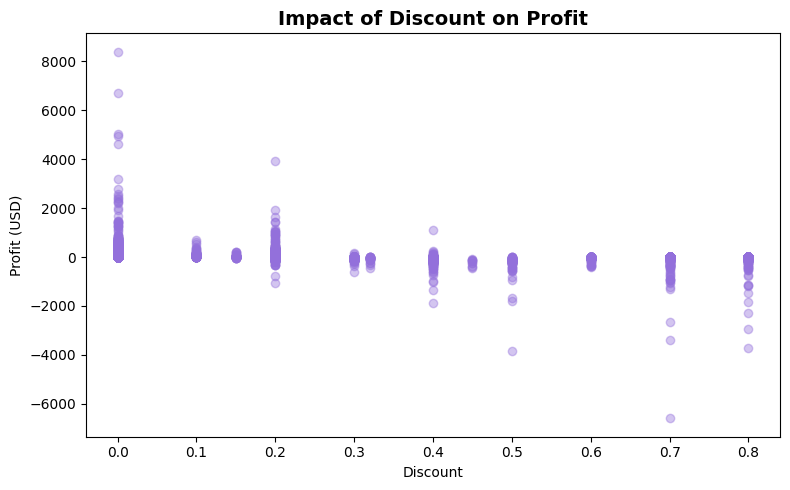

In [14]:
# Visualizing the impact of discount on profit
plt.figure(figsize=(8, 5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.4, color='mediumpurple')
plt.title('Impact of Discount on Profit', fontsize=14, fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Profit (USD)')
plt.tight_layout()
plt.savefig('viz8_discount_vs_profit.png', dpi=150)
plt.show()

In [25]:
# Summary of the data visualization project
print("-" * 55)
print("DATA VISUALIZATION SUMMARY")
print("Global Superstore Sales Dataset")
print("-" * 55)
print("Dataset: 9,994 sales records, 21 features")
print("Source: Kaggle - Global Superstore Dataset")
print("")
print("VISUALIZATIONS CREATED:")
print("1. Total Sales by Region - Bar Chart")
print("2. Total Profit by Category - Bar Chart")
print("3. Sales Trend Over the Years - Line Chart")
print("4. Sales vs Profit Relationship - Scatter Plot")
print("5. Top 10 Products by Sales - Horizontal Bar Chart")
print("6. Sales Share by Customer Segment - Pie Chart")
print("7. Profit Distribution by Region - Box Plot")
print("8. Impact of Discount on Profit - Scatter Plot")
print("")
print("KEY INSIGHTS:")
print("1. The West region generates the highest total sales")
print("2. Technology is the most profitable product category")
print("3. Sales have grown consistently year over year")
print("4. Higher discounts tend to result in lower profits")
print("5. The Consumer segment accounts for the largest")
print("   share of total sales")
print("")
print("TOOLS USED: Matplotlib, Seaborn")
print("-" * 55)

-------------------------------------------------------
DATA VISUALIZATION SUMMARY
Global Superstore Sales Dataset
-------------------------------------------------------
Dataset: 9,994 sales records, 21 features
Source: Kaggle - Global Superstore Dataset

VISUALIZATIONS CREATED:
1. Total Sales by Region - Bar Chart
2. Total Profit by Category - Bar Chart
3. Sales Trend Over the Years - Line Chart
4. Sales vs Profit Relationship - Scatter Plot
5. Top 10 Products by Sales - Horizontal Bar Chart
6. Sales Share by Customer Segment - Pie Chart
7. Profit Distribution by Region - Box Plot
8. Impact of Discount on Profit - Scatter Plot

KEY INSIGHTS:
1. The West region generates the highest total sales
2. Technology is the most profitable product category
3. Sales have grown consistently year over year
4. Higher discounts tend to result in lower profits
5. The Consumer segment accounts for the largest
   share of total sales

TOOLS USED: Matplotlib, Seaborn
-----------------------------------